In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression


## loading dataset

In [2]:
columns = ['sepal length','sepal width','petal length','petal width','class_labels']
iris = pd.read_csv(r"C:\Users\user\Music\IrisFlowerClassification-main\IrisFlowerClassification-main\iris.data.csv", names =columns)

In [3]:
# Features and Target
X = iris.iloc[:, :-1]  # first 4 columns
y = iris['class_labels']

In [4]:
iris.head()

,sepal length,sepal width,petal length,petal width,class_labels
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
iris.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## visualization  of dataset 

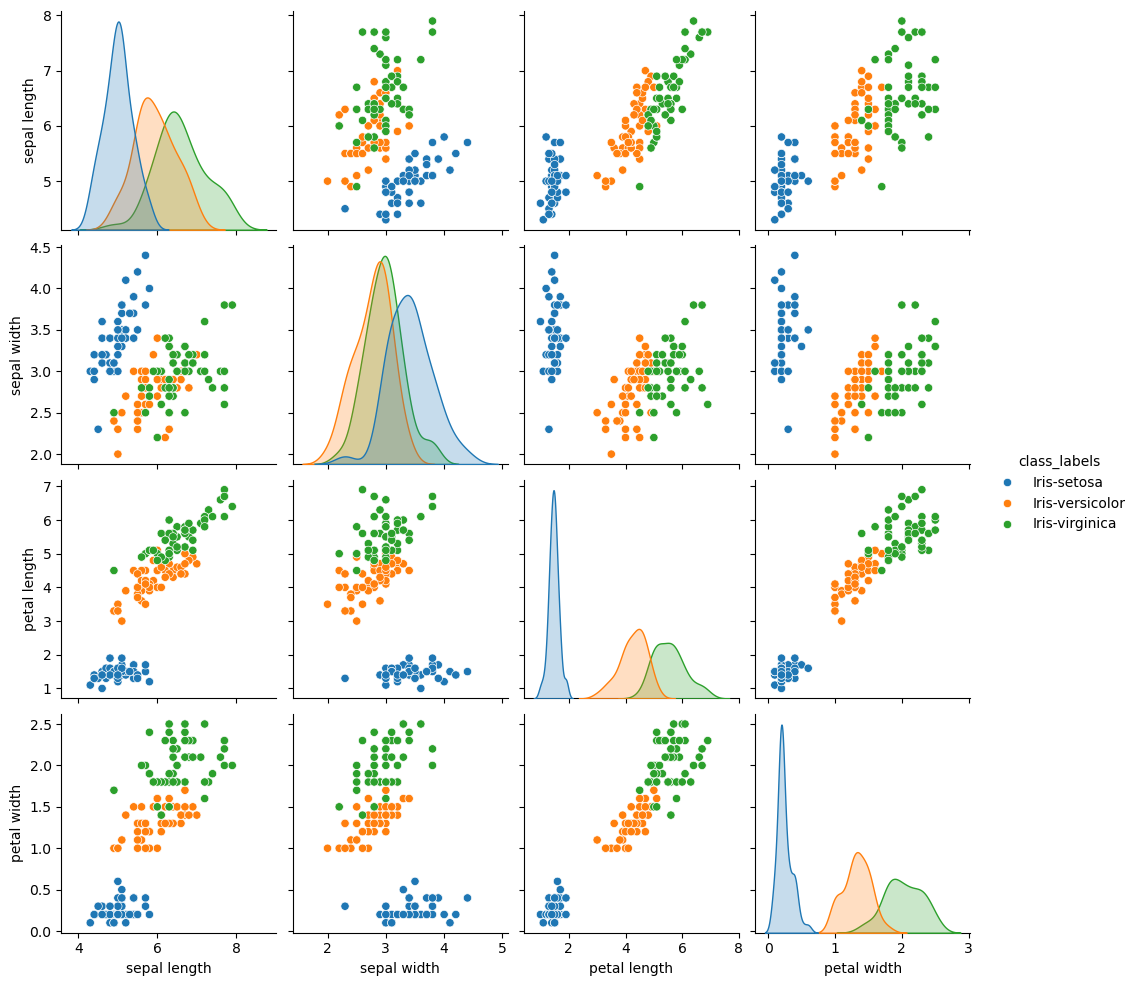

In [6]:
sns.pairplot(iris, hue = 'class_labels')

## seperating input columns and the output column

In [7]:
data = iris.values

x = data[:,0:4]
y = data[:,4]

## model 2 : logistic regression 

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
print(x_train.shape, x_test.shape)


(120, 4) (30, 4)


In [10]:
model_LR = LogisticRegression(solver='liblinear',max_iter=1000)
model_LR.fit(x_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [11]:
# Predictions
y_train_pred = model_LR.predict(x_train)
y_test_pred = model_LR.predict(x_test)

# print(y_test_pred)
# print(y_train_pred)

In [12]:
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9583333333333334
Test Accuracy: 1.0


In [13]:
predict = model_LR.predict(x_test)

#calculate the accuracy 
print(accuracy_score(y_test, predict)*100)
for i in range(len(predict)):
    print(y_test[i] , predict[i])

100.0
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-virginica Iris-virginica
Iris-versicolor Iris-versicolor
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-virginica Iris-virginica
Iris-versicolor Iris-versicolor
Iris-versicolor Iris-versicolor
Iris-virginica Iris-virginica
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-virginica Iris-virginica
Iris-versicolor Iris-versicolor
Iris-versicolor Iris-versicolor
Iris-virginica Iris-virginica
Iris-setosa Iris-setosa
Iris-virginica Iris-virginica
Iris-setosa Iris-setosa
Iris-virginica Iris-virginica
Iris-virginica Iris-virginica
Iris-virginica Iris-virginica
Iris-virginica Iris-virginica
Iris-virginica Iris-virginica
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa


In [14]:
print(classification_report(y_test, predict))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [28]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

#Cross-validation setup (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Get cross-validated predictions
y_pred = cross_val_predict(model_LR, x, y, cv=cv)

# Evaluation
print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred, target_names=iris["class_labels"].unique()))


Accuracy: 0.96

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.98      0.90      0.94        50
 Iris-virginica       0.91      0.98      0.94        50

       accuracy                           0.96       150
      macro avg       0.96      0.96      0.96       150
   weighted avg       0.96      0.96      0.96       150



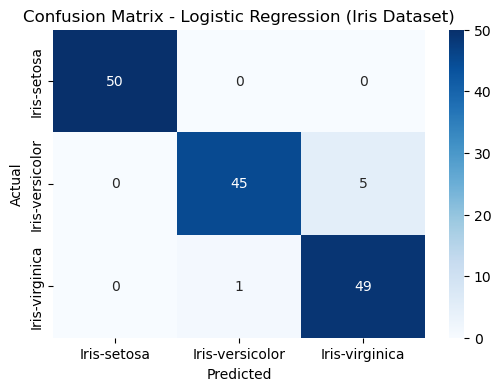

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred, labels=np.unique(y))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Iris Dataset)")
plt.show()